In [1]:
import kagglehub
import pandas as pd
import os


# Download latest version
path = kagglehub.dataset_download("mahmoudreda55/satellite-image-classification")

print("Path to dataset files:", path)

data_dir = os.path.join(path, "data")
rows = []

for label in os.listdir(data_dir):
    class_path = os.path.join(data_dir, label)
    
    if os.path.isdir(class_path):
        for img in os.listdir(class_path):
            img_path = os.path.join(class_path, img)
            rows.append([img_path, label])

df = pd.DataFrame(rows, columns=["image_path", "label"])
df.to_csv("satellite_dataset.csv", index=False)

print(df.head())

/home/arianbahram/satellite-image-classification-ml/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/arianbahram/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1
                                          image_path   label
0  /home/arianbahram/.cache/kagglehub/datasets/ma...  cloudy
1  /home/arianbahram/.cache/kagglehub/datasets/ma...  cloudy
2  /home/arianbahram/.cache/kagglehub/datasets/ma...  cloudy
3  /home/arianbahram/.cache/kagglehub/datasets/ma...  cloudy
4  /home/arianbahram/.cache/kagglehub/datasets/ma...  cloudy


Dataset Exploration

In [2]:
images = df.groupby("label")["image_path"].apply(list).to_dict()
image_count = df['label'].value_counts().to_dict()
print(image_count)
total_images = len(df)
print(f"Total images: {total_images}")

{'cloudy': 1500, 'water': 1500, 'green_area': 1500, 'desert': 1131}
Total images: 5631


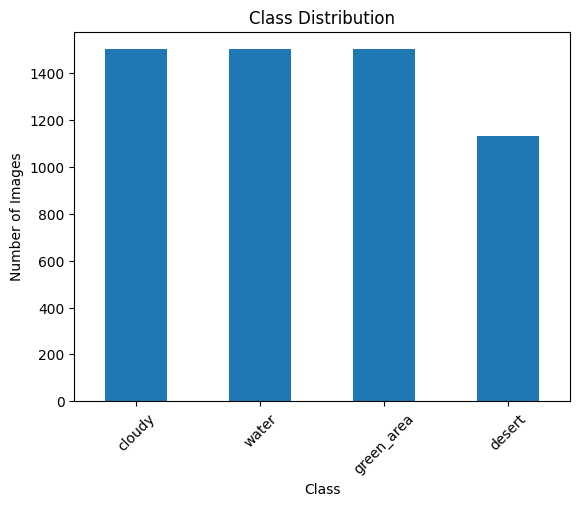

In [3]:
import matplotlib.pyplot as plt

counts = df['label'].value_counts()

plt.figure()
counts.plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

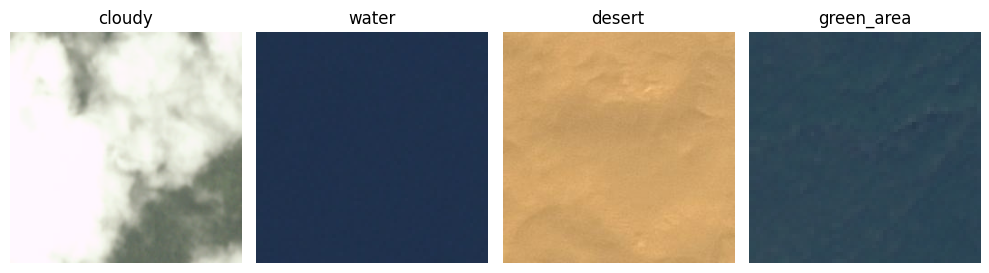

In [5]:
from PIL import Image
plt.figure(figsize=(10, 6))

for i, label in enumerate(df['label'].unique()):
    sample = df[df['label'] == label].sample(1).iloc[0]
    img = Image.open(sample['image_path'])
    
    plt.subplot(1, 4, i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [6]:
sizes = []

for path in df['image_path'][:200]:  # sample for speed
    img = Image.open(path)
    sizes.append(img.size)

print(set(sizes))

{(256, 256)}


In [7]:
import numpy as np

img = Image.open(df.iloc[0]['image_path'])
img_array = np.array(img)

print("Shape:", img_array.shape)
print("Min pixel:", img_array.min())
print("Max pixel:", img_array.max())

Shape: (256, 256, 4)
Min pixel: 0
Max pixel: 78
